In [1]:
import numpy as np
import matplotlib.pyplot as plt

from phase.utils import aia, remove_carrier

REPO_ROOT = "/Users/rodionsa/Library/CloudStorage/GoogleDrive-sergeyrodionov93@gmail.com/My Drive/work/Projects/HoloEML/holoeml-processing"
DATA_DIR = REPO_ROOT + "/data/"

delta_crop = 400

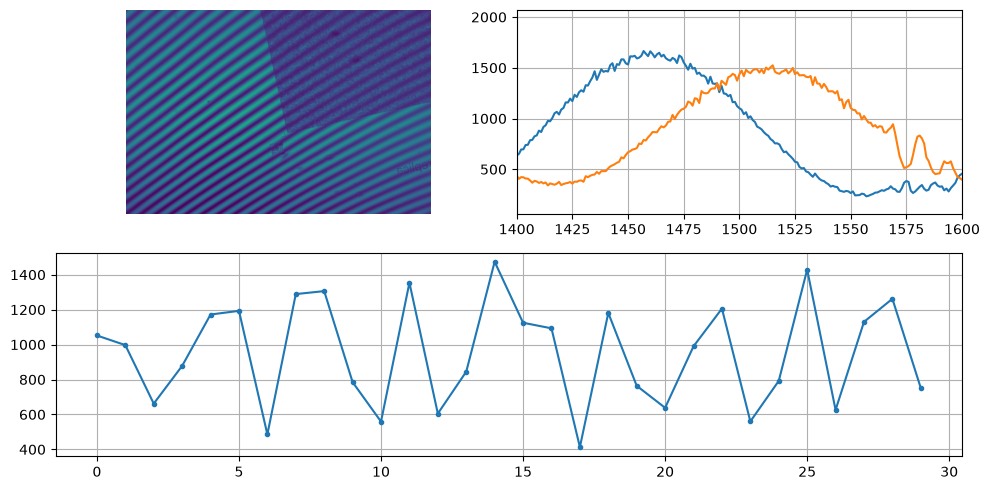

In [90]:
# Read data
data = np.load(DATA_DIR + "piezo_scan_meta_20260721_180617.npz")
images = data['images'][:, delta_crop:3000-delta_crop, delta_crop:4096-delta_crop,0]
volts = data['volts']

plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.imshow(images[0])
plt.axis('off')

plt.subplot(2, 2, 2)
plt.plot(images[0, 1500])
plt.plot(images[6, 1500])
plt.xlim([1400, 1600])
plt.grid()

plt.subplot(2, 2, (3,4))
plt.plot(images[:, 1500, 2000], ".-")
plt.grid()

plt.tight_layout()

In [91]:
# Extract phase
results = aia(images)

a = results.a
b = results.b
phi = results.phi
delta = results.delta

print(f"Converged: {results.converged}")
print(f"Kappa_p: {results.kappa_p}")
print(f"Kappa_ps: {results.kappa_ps}")
print(f"Predicted RMS: {results.predicted_rms}")

Converged: True
Kappa_p: 2.25812953105757
Kappa_ps: 2.1531325335878173
Predicted RMS: 0.040167420630706524


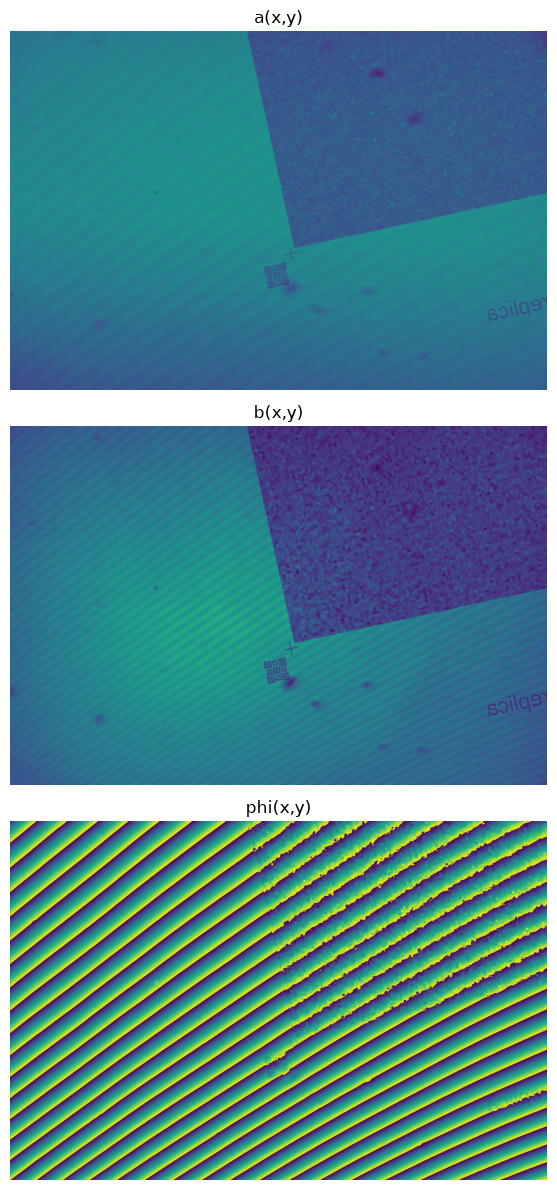

In [92]:
# Plot a, b and phi
plt.figure(figsize=(6, 12))

plt.subplot(311)
plt.title("a(x,y)")
plt.imshow(a)
plt.axis("off")

plt.subplot(312)
plt.title("b(x,y)")
plt.imshow(b)
plt.axis("off")

plt.subplot(313)
plt.title("phi(x,y)")
plt.imshow(phi)
plt.axis("off")

plt.tight_layout()

In [93]:
# Remove phase carrier
carrier_results = remove_carrier(phi, b, defocus=False, refine_iters=10, n_blocks=10)
phi_clean = carrier_results.phi

print(f"kx/2pi: {carrier_results.fx}")
print(f"ky/2pi: {carrier_results.fy}")
print(f"kxx: {carrier_results.kxx}")
print(f"kyy: {carrier_results.kyy}")
print(f"kxy: {carrier_results.kxy}")
print(f"piston: {carrier_results.piston}")

kx/2pi: 0.0050572219739852126
ky/2pi: 0.0077487303736136605
kxx: 0.0
kyy: 0.0
kxy: 0.0
piston: -0.273925251388748


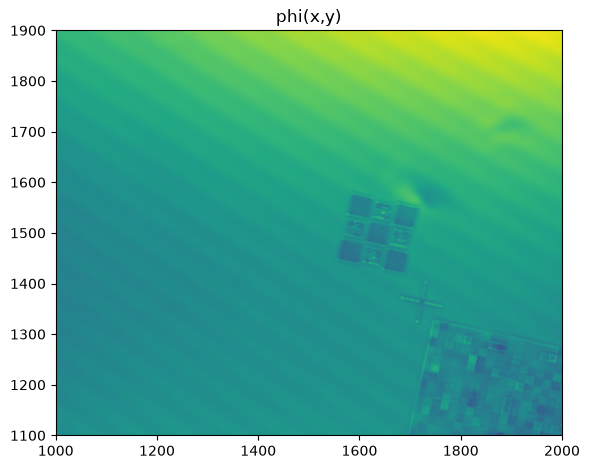

In [95]:
# Plot phi_clean
plt.figure(figsize=(6, 6))

plt.title("phi(x,y)")
plt.imshow(phi_clean)
plt.xlim([1000, 2000])
plt.ylim([1100, 1900])

plt.tight_layout()

(1500.0, 2000.0)

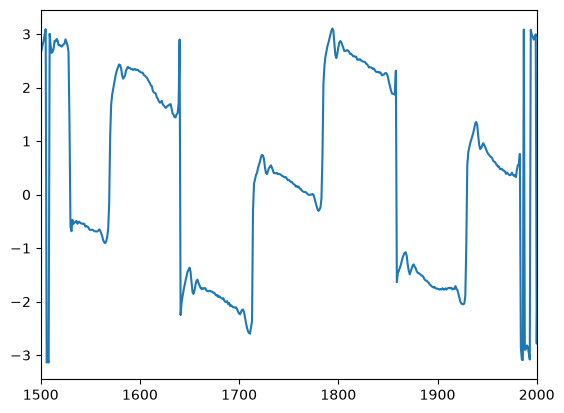

In [89]:
plt.plot(phi_clean[1500,:])
plt.xlim([1500, 2000])